# Employee Attrition Prediction using Machine Learning

## Internship Project - Week 2

### Task 1 : Data Loading and Exploration

In this task, we will load the dataset and understand its basic information such as rows, columns, target variable, and employee attrition rate.

In [167]:
# importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# this line removes unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

In [168]:
# loading the dataset

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [169]:
# displaying first 10 rows of dataset

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Observation

The dataset has employee information like age, salary, department, job role, work-life balance, and attrition status.

In [170]:
# checking number of rows and columns

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


### Observation

The dataset contains 1470 rows and 35 columns.

In [171]:
# displaying all column names

df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [172]:
# checking information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Observation

The dataset contains both numerical and categorical columns. There are no missing values visible in the dataset information.

In [173]:
# checking target column

df["Attrition"].head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: str

### Observation

The target column is Attrition, which contains two values:
- Yes (Employee Left)
- No (Employee Stayed)

In [174]:
# counting employees who stayed and left

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [175]:
# calculating attrition rate

attrition_rate = (df["Attrition"] == "Yes").mean() * 100
print("Attrition Rate :", round(attrition_rate, 2), "%")

Attrition Rate : 16.12 %


### Observation

Only around 16% of employees have left the company, while about 84% stayed.

This means the dataset is imbalanced because the number of employees who stayed is much higher than those who left.

In [176]:
# checking numerical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
print("Number of Numerical Columns :", len(numerical_columns))

Number of Numerical Columns : 26


In [177]:
# checking categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns
print("Number of Categorical Columns :", len(categorical_columns))

Number of Categorical Columns : 9


In [178]:
# displaying numerical columns
numerical_columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

In [179]:
# displaying categorical columns
categorical_columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

In [180]:
# statistical summary of numerical columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Observation #TASK 1

The average employee age is around 37 years.

Monthly income varies significantly among employees.

Some features have a wide range of values, which indicates that feature scaling may be useful before model training.

# Task 2 : Data Cleaning & Preprocessing

In this task, we will clean the dataset and prepare it for machine learning.

The following steps are performed:
- Check missing values
- Remove unnecessary columns
- Convert target column into numeric values
- Encode categorical columns
- Scale numerical features

In [181]:
# checking missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

There are no missing values in the dataset. Therefore, no missing value treatment is required.

In [182]:
# checking duplicate rows
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Observation

There are no duplicate records in the dataset.

In [183]:
# removing unnecessary columns

df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

In [184]:
# checking new shape

print(df.shape)

(1470, 31)


### Observation
Irrelevant columns were removed because they do not provide useful information for predicting employee attrition
EmployeeNumber was removed because it is only a unique identifier and does not help predict attrition. EmployeeCount, Over18, and StandardHours were removed because they have the same value for every employee and do not provide useful information for the model.

In [185]:
# converting target column into numeric values

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [186]:
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

### Observation

The target column has been converted into numerical values for machine learning models.

In [187]:
# finding categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')

In [188]:
# converting categorical columns into numeric values

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [189]:
print(df.shape)

(1470, 45)


### Observation

All categorical columns have been converted into numerical format using One-Hot Encoding.

In [190]:
# separating input and output

X = df.drop("Attrition", axis=1)
y = df["Attrition"]
from sklearn.preprocessing import StandardScaler

In [191]:
# selecting numerical columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [192]:
# scaling numerical features

scaler = StandardScaler()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

In [193]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


### Observation 

Numerical features have been scaled using StandardScaler. Scaling helps machine learning models perform better by bringing all numerical values to a similar range.

In [194]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)
print(df.head())

Shape of X : (1470, 44)
Shape of y : (1470,)
   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2         1   
3                        4          56               3         1   
4                        1          40               3         1   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0                4  ...                          False            False   
1                2  ...      

In [195]:
df = pd.get_dummies(...)

# Task 3 : Exploratory Data Analysis (EDA)

In this task, we will explore the dataset using different visualizations to understand the factors affecting employee attrition.

In [196]:
# loading original dataset for EDA

eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [197]:
# converting target column

eda_df["Attrition"] = eda_df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

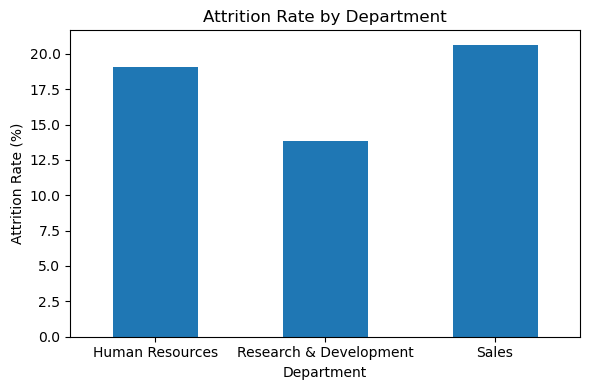

In [198]:
# attrition by department

department_attrition = eda_df.groupby("Department")["Attrition"].mean() * 100
plt.figure(figsize=(6,4))

department_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/chart1_department.png")

plt.show()

### Observation

The Sales department has the highest attrition rate (around 20.6%), followed by Human Resources (around 19.0%). Research & Development has the lowest attrition rate (around 13.8%). This indicates that HR should focus more on retaining employees in the Sales department.

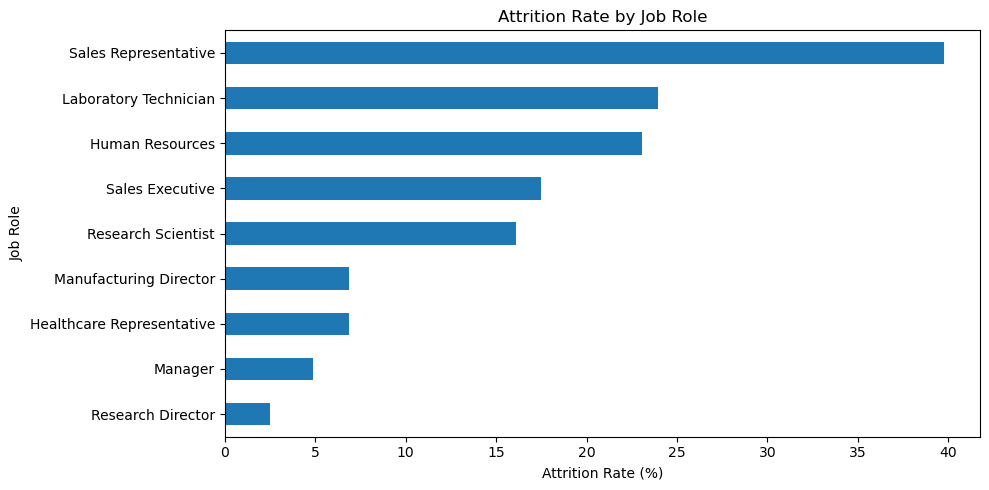

In [199]:
# attrition by job role

jobrole_attrition = eda_df.groupby("JobRole")["Attrition"].mean() * 100
plt.figure(figsize=(10,5))
jobrole_attrition.sort_values().plot(kind="barh")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()

plt.savefig("charts/chart2_jobrole.png")

plt.show()

### Observation

Sales Representatives have the highest attrition rate (around 40%), followed by Laboratory Technicians (around 24%) and Human Resources employees (around 23%). Research Directors and Managers have the lowest attrition rates, indicating that employees in these roles are more likely to stay with the company.

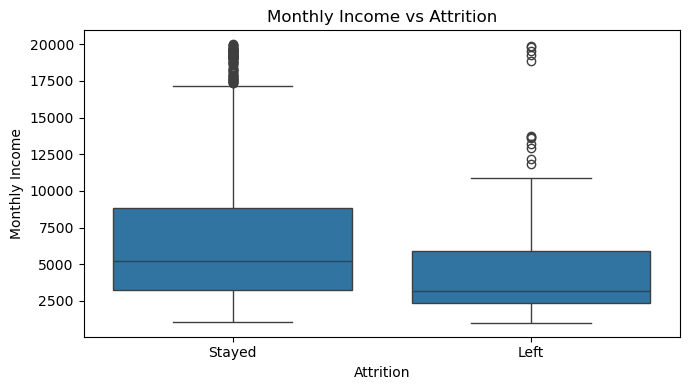

In [200]:
# income comparison

plt.figure(figsize=(7,4))
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.xticks([0,1],["Stayed","Left"])

plt.tight_layout()

plt.savefig("charts/chart3_income.png")

plt.show()

### Observation

Employees who left generally have lower monthly income compared to employees who stayed.

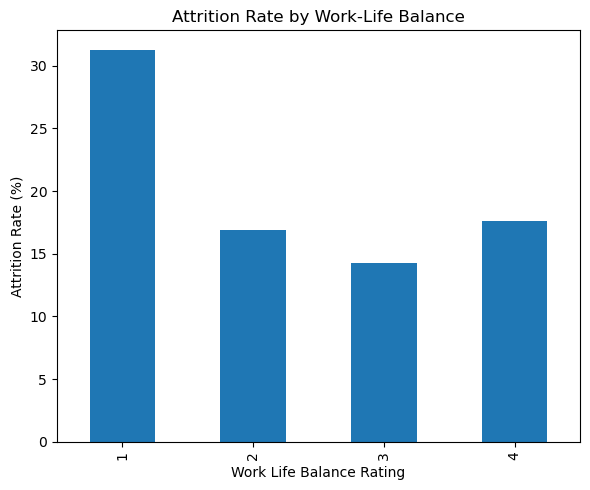

In [201]:
# work life balance

worklife = eda_df.groupby("WorkLifeBalance")["Attrition"].mean() * 100
plt.figure(figsize=(6,5))

worklife.plot(kind="bar")
plt.title("Attrition Rate by Work-Life Balance")

plt.xlabel("Work Life Balance Rating")

plt.ylabel("Attrition Rate (%)")
plt.tight_layout()

plt.savefig("charts/chart4_worklife.png")

plt.show()

### Observation

Employees with a Work-Life Balance rating of **1** have the highest attrition rate (around **31%**). Employees with a rating of **3** have the lowest attrition rate (around **14%**). This indicates that poor work-life balance is associated with a higher chance of employees leaving the company.

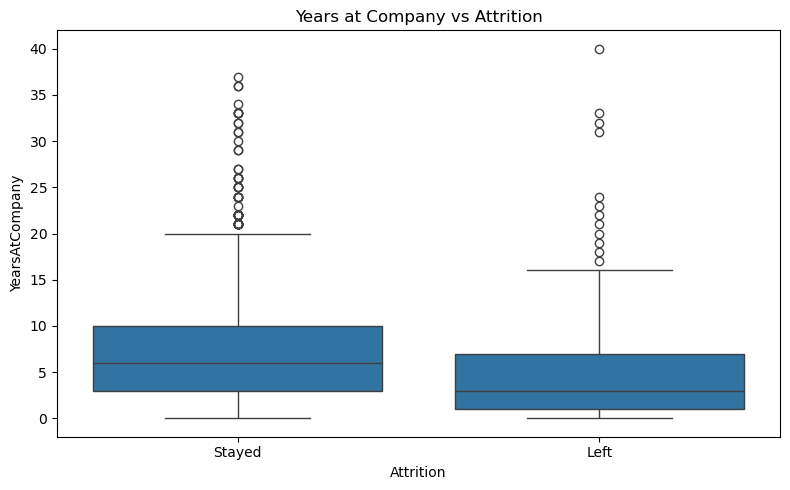

In [202]:
# years at company

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=eda_df
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Years at Company vs Attrition")

plt.tight_layout()

plt.savefig("charts/chart5_years.png")

plt.show()

### Observation #TASK 3

Many employees who leave the company have spent fewer years at the organization compared to employees who stay.

## Business Insights

1. The highest attrition Rate is observed in the Sales Department, indicating that HR should focus more on retaining    employees in this department.

2. Sales Representatives and Laboratory Technicians show higher attrition rates than many Other job Roles.
3. Employees with lower monthly income are more likely to leave the company.

4. Employees with poor work-life Balance have a Higher chance of leaving the organization.

5. Most Employees who leave have spent relatively fewer years at the C, Suggesting that early employee engagement and retention efforts are important.

# Task 4 : Model Building and Comparison

In this task, we will train different machine learning models to predict employee attrition
The dataset is divided into training and testing sets. Three classification models are trained and their performance is compared.

In [203]:
# importing required libraries

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score

In [204]:
# splitting dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,

    stratify=y

)
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (1176, 44)
Testing Data Shape : (294, 44)


80% of the data is used for training and 20% is used for testing.
Stratified sampling is used to maintain the same proportion of attrition classes in both datasets.

In [205]:
# creating logistic regression model
model1 = LogisticRegression(

    class_weight="balanced",

    random_state=42,

    max_iter=1000
)

# training model

model1.fit(X_train, y_train)
# making prediction

prediction1 = model1.predict(X_test)
# calculating accuracy
accuracy1 = accuracy_score(y_test, prediction1)

print("Logistic Regression Accuracy :", round(accuracy1,4))

Logistic Regression Accuracy : 0.7551


In [206]:
# creating random forest model

model2 = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight="balanced"

)

# training model

model2.fit(X_train, y_train)
# prediction

prediction2 = model2.predict(X_test)
# accuracy
accuracy2 = accuracy_score(y_test, prediction2)

print("Random Forest Accuracy :", round(accuracy2,4))

Random Forest Accuracy : 0.8435


In [207]:
# creating gradient boosting model

model3 = GradientBoostingClassifier(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42

)

# training model

model3.fit(X_train, y_train)
# prediction

prediction3 = model3.predict(X_test)
# accuracy

accuracy3 = accuracy_score(y_test,prediction3)

print("Gradient Boosting Accuracy :",round(accuracy3,4))

Gradient Boosting Accuracy : 0.8503


In [208]:
# creating comparison table
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        round(accuracy1,4),
        round(accuracy2,4),
        round(accuracy3,4)
    ]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
2,Gradient Boosting,0.8503
1,Random Forest,0.8435
0,Logistic Regression,0.7551


### Observation #TASK 4

Three machine learning models were trained and compared using the employee attrition dataset.

Among all the models, Gradient Boosting achieved the highest accuracy (85.03%), followed by Random Forest (84.35%) and Logistic Regression (75.51%).

Based on the accuracy results, Gradient Boosting is selected as the best model for further evaluation.

# Task 5 : Model Evaluation

In this task, we will evaluate all the machine learning models using different evaluation metrics.
The metrics used are:
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

Finally, we will identify the best performing model.

In [209]:
# importing evaluation metrics

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [210]:
# calculating evaluation metrics for all models

precision1 = precision_score(y_test, prediction1)
recall1 = recall_score(y_test, prediction1)
f1_1 = f1_score(y_test, prediction1)
roc1 = roc_auc_score(y_test, model1.predict_proba(X_test)[:,1])

precision2 = precision_score(y_test, prediction2)
recall2 = recall_score(y_test, prediction2)
f1_2 = f1_score(y_test, prediction2)
roc2 = roc_auc_score(y_test, model2.predict_proba(X_test)[:,1])

precision3 = precision_score(y_test, prediction3)
recall3 = recall_score(y_test, prediction3)
f1_3 = f1_score(y_test, prediction3)
roc3 = roc_auc_score(y_test, model3.predict_proba(X_test)[:,1])

In [211]:
# comparing all models

result = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy1,
        accuracy2,
        accuracy3
    ],
    "Precision":[
        precision1,
        precision2,
        precision3
    ],

    "Recall":[
        recall1,
        recall2,
        recall3
    ],

    "F1 Score":[
        f1_1,
        f1_2,
        f1_3
    ],
    "ROC-AUC":[
        roc1,
        roc2,
        roc3
    ]
})

result = result.round(3)
result.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.850,0.588,0.213,0.312,0.794
1,Random Forest,0.844,0.571,0.085,0.148,0.772
0,Logistic Regression,0.755,0.356,0.660,0.463,0.804


In [212]:
print("Logistic Regression\n")

print(classification_report(y_test, prediction1))

Logistic Regression

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [213]:
print("Random Forest\n")

print(classification_report(y_test, prediction2))

Random Forest

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294



In [214]:
print("Gradient Boosting\n")

print(classification_report(y_test, prediction3))

Gradient Boosting

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



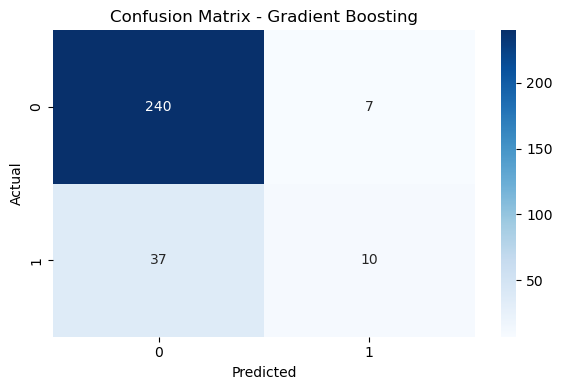

In [215]:
# confusion matrix for best model

cm = confusion_matrix(y_test, prediction3)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Gradient Boosting")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("charts/chart6_confusion_matrix.png")

plt.show()

### Observation

The Gradient Boosting model correctly predicted **240 employees who stayed** and **10 employees who left**.
The model incorrectly predicted **7 employees as leaving when they actually stayed** and **37 employees as staying when they actually left**.
This indicates that the model performs well in identifying employees who stay but still misses several employees who are likely to leave.

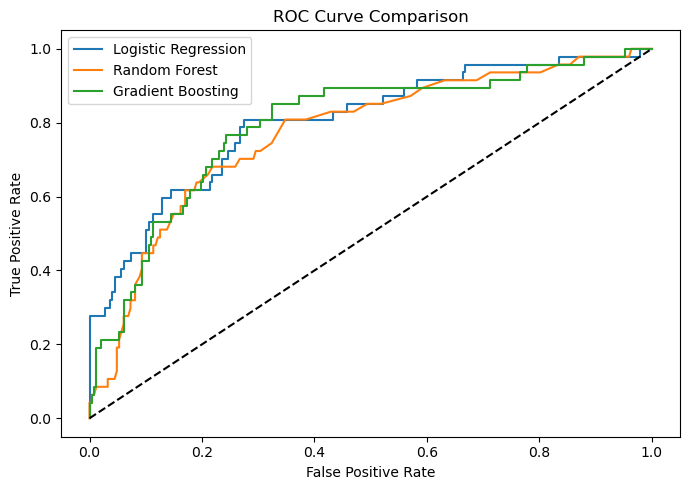

In [216]:
# probability prediction

prob1 = model1.predict_proba(X_test)[:,1]
prob2 = model2.predict_proba(X_test)[:,1]
prob3 = model3.predict_proba(X_test)[:,1]
# ROC values

fpr1, tpr1, _ = roc_curve(y_test, prob1)

fpr2, tpr2, _ = roc_curve(y_test, prob2)
fpr3, tpr3, _ = roc_curve(y_test, prob3)

# plotting ROC curve

plt.figure(figsize=(7,5))

plt.plot(fpr1, tpr1, label="Logistic Regression")

plt.plot(fpr2, tpr2, label="Random Forest")

plt.plot(fpr3, tpr3, label="Gradient Boosting")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("charts/chart7_roc_curve.png")

plt.show()

In [217]:
# creating feature importance dataframe

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model3.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047100
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043015
4,EnvironmentSatisfaction,0.038851
6,JobInvolvement,0.038142


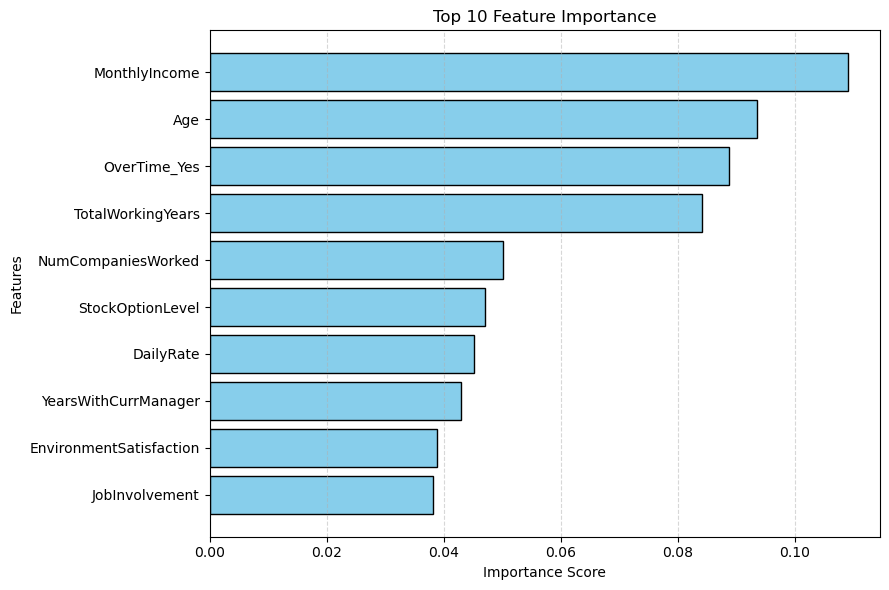

In [218]:
# plotting top 10 important features

top10 = feature_importance.head(10)

plt.figure(figsize=(9,6))

plt.barh(
    top10["Feature"],
    top10["Importance"],
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("charts/chart8_feature_importance.png")

plt.show()

### Observation (TOP 10 FEATURES)

According to the Gradient Boosting model, **Monthly Income** is the most important factor influencing employee attrition, followed by **Age**, **OverTime**, and **Total Working Years**.
These features contribute the most to predicting whether an employee is likely to leave the company.

## Conclusion #TASK 5

Among the three models, **Gradient Boosting** achieved the highest accuracy (**85.03%**) and was selected as the best model for this project.

The model identified **Monthly Income**, **Age**, **OverTime**, and **Total Working Years** as the most important factors affecting employee attrition.

Although Logistic Regression achieved a higher Recall, Gradient Boosting provided the best overall performance and was therefore chosen for feature importance analysis and business recommendations.

# Task 6 : Data Visualization

In this task, different charts are created to understand employee attrition and model performance.

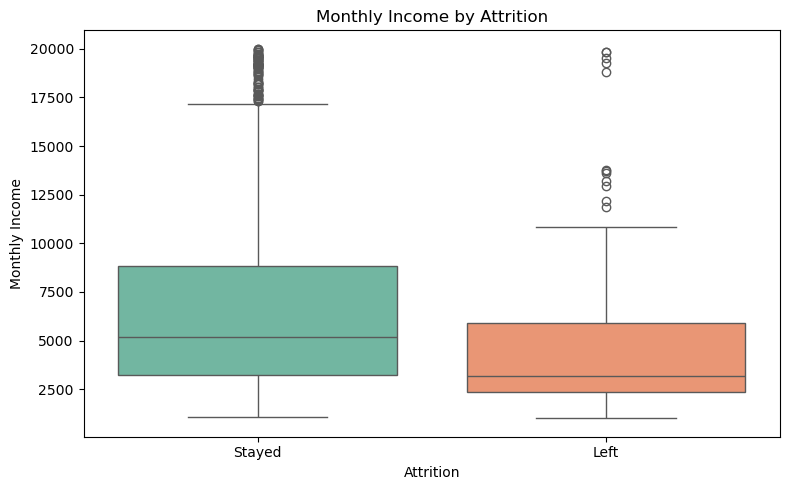

In [219]:
# monthly income comparison

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df,
    palette="Set2"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.xticks([0,1],["Stayed","Left"])

plt.tight_layout()

plt.savefig("charts/chart3_income_boxplot.png")

plt.show()

### Observation

Employees who left the company generally have lower monthly income compared to employees who stayed.

However, salary is not the only factor affecting employee attrition.

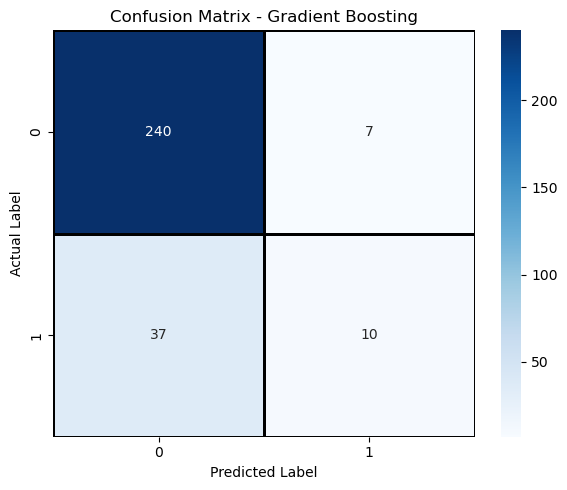

In [220]:
# confusion matrix

cm = confusion_matrix(y_test,prediction3)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black"
)

plt.title("Confusion Matrix - Gradient Boosting")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig("charts/chart4_confusion_matrix.png")

plt.show()

### Observation

The model correctly classified most employees who stayed in the company. However, it missed some employees who actually left, indicating that there is still scope for improving recall.

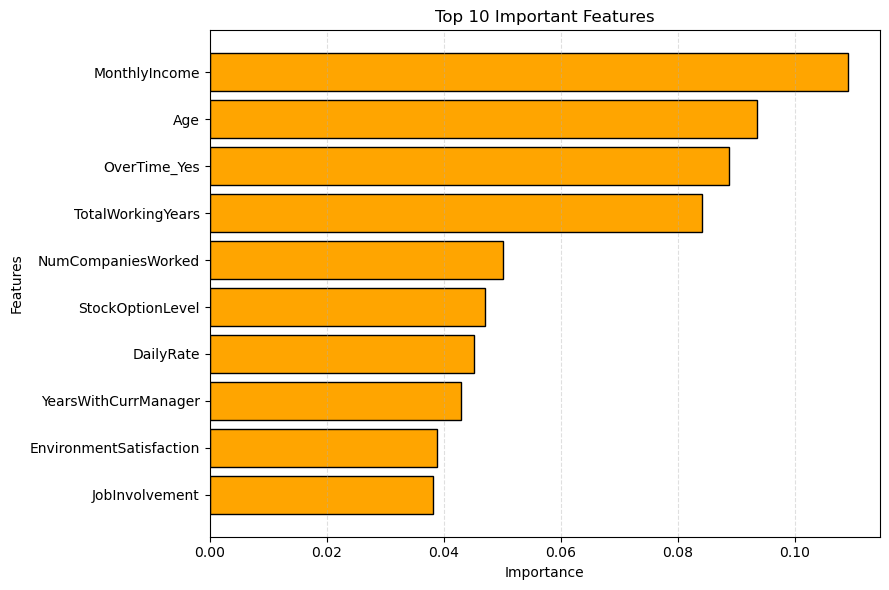

In [221]:
# top 10 important features
top10 = feature_importance.head(10)
plt.figure(figsize=(9,6))

plt.barh(

    top10["Feature"],

    top10["Importance"],

    color="orange",
    edgecolor="black"

)
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.grid(axis="x",linestyle="--",alpha=0.4)

plt.tight_layout()

plt.savefig("charts/chart5_feature_importance.png")

plt.show()

### Observation

Monthly Income, Age, OverTime, and Total Working Years are the most important features influencing employee attrition according to the Gradient Boosting model.

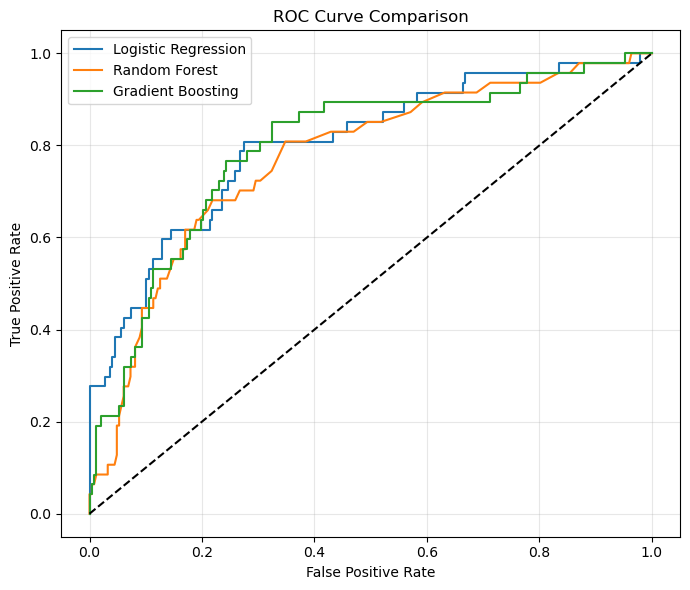

In [222]:
# plotting ROC curve

plt.figure(figsize=(7,6))
plt.plot(fpr1,tpr1,label="Logistic Regression")

plt.plot(fpr2,tpr2,label="Random Forest")

plt.plot(fpr3,tpr3,label="Gradient Boosting")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("charts/chart6_roc_curve.png")

plt.show()

### Observation

The ROC curves show that all three models perform better than random guessing. Gradient Boosting and Logistic Regression demonstrate stronger discrimination between employees who stay and those who leave.

# Task 7 : HR Insights & Business Recommendations

Based on the analysis and machine learning model, the following business insights and recommendations are provided for the HR team.

### 1. Which three factors most strongly predict employee attrition?

According to the analysis, the three most important factors influencing employee attrition are:
- Monthly Income
- Age
- Overtime

Employees with lower salaries, younger employees, and employees who frequently work overtime are more likely to leave the company.

### 2. Which department or job role should HR prioritize?

The Sales department has the highest employee attrition rate among all departments.

Among different job roles, Sales Representatives have the highest attrition rate. HR should prioritize retention efforts for employees working in Sales, especially Sales Representatives.

### 3. Does salary alone explain employee attrition?

No
Although Monthly Income is one of the most important factors, employee attrition is also influenced by Age, Overtime, Total Working Years, Environment Satisfaction, and Job Involvement.

This shows that employee attrition is caused by multiple factors rather than salary alone.

### 3. Does salary alone explain employee attrition?

N
Although Monthly Income is one of the most important factors, employee attrition is also influenced by Age, Overtime, Total Working Years, Environment Satisfaction, and Job Involvement.

This shows that employee attrition is caused by multiple factors rather than salary alone.

### 5. Limitation of the Model

The model predicts employee attrition based only on the available historical data.
It does not consider personal reasons such as family issues, health conditions, job opportunities in other companies, or employee satisfaction surveys that may also influence an employee's decision to leave.

# Conclusion

In this project, an Employee Attrition Prediction model was developed using Machine Learning techniques.
After comparing multiple models, Gradient Boosting achieved the highest overall accuracy of approximately **85%** and was selected as the best-performing model.

The analysis showed that **Monthly Income**, **Age**, **OverTime**, and **Total Working Years** are the most important factors affecting employee attrition.

The Sales department and Sales Representatives experience the highest employee turnover. By improving employee engagement, reducing excessive overtime, and providing better career growth opportunities, HR can reduce attrition and improve employee retention.